# MNIST Classification (V2: Dropout + Early Stopping)

This experiment builds on the baseline ANN model by introducing regularization techniques:
- Dropout to reduce overfitting
- EarlyStopping to halt training when validation performance stops improving

The goal is to improve generalization while avoiding unnecessary training.

In [1]:
# IMPORTS :

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist

### Load Dataset : ### 

We use the MNIST dataset of handwritten digits (0–9).

In [2]:
# DATA LOAD : 

(X_train, y_train), (X_test, y_test) = mnist.load_data()

### Data Preprocessing: ###
- Normalize pixel values (0–255 → 0–1)
- Flatten images (28×28 → 784)

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

### Model Architecture: ###
- Dense layer with 256 neurons
- Dropout (0.2) to reduce overfitting
- Output layer (10 classes)

In [4]:
model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(784,))) 

model.add(Dropout(0.3))  # Helps prevent overfitting by randomly dropping neurons. 

model.add(Dense(10, activation='softmax'))

In [5]:
# MODEL COMPILE :

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Early Stopping: ###
Training stops automatically when validation loss does not improve.
This prevents overfitting and saves computation time.

In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Model Training: ###
Train the model with validation monitoring and early stopping.

In [7]:
history = model.fit(X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9205 - loss: 0.2717 - val_accuracy: 0.9630 - val_loss: 0.1229
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9608 - loss: 0.1286 - val_accuracy: 0.9731 - val_loss: 0.0907
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9710 - loss: 0.0946 - val_accuracy: 0.9749 - val_loss: 0.0783
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9753 - loss: 0.0790 - val_accuracy: 0.9762 - val_loss: 0.0725
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9798 - loss: 0.0640 - val_accuracy: 0.9792 - val_loss: 0.0685
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9818 - loss: 0.0572 - val_accuracy: 0.9799 - val_loss: 0.0641
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9832 - loss: 0.0514 - val_accuracy: 0.9816 - val_loss: 0.0603
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9843 - loss: 0.0465 - 

### Accuracy Plot: ###
Compare training and validation accuracy.

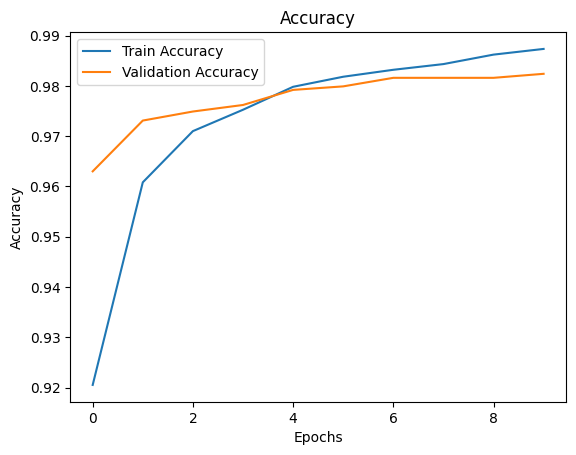

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

### Loss Plot: ###
Helps visualize overfitting behavior.

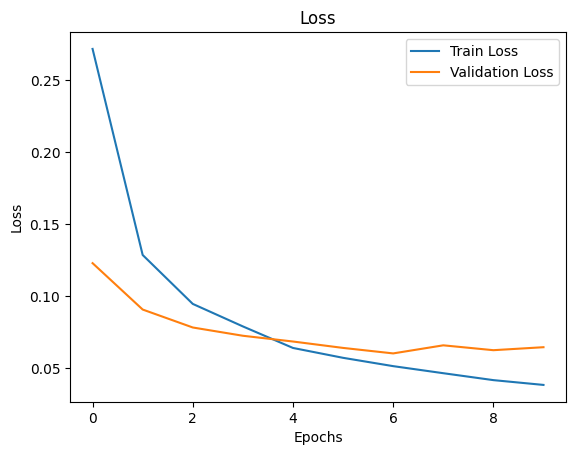

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train Loss', 'Validation Loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

### Model Evaluation: ###
Evaluate performance on test data.

In [10]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9816 - loss: 0.0603 


[0.060253288596868515, 0.9815999865531921]

### Visual Check (Predictions): ###
Display a sample image with predicted label.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


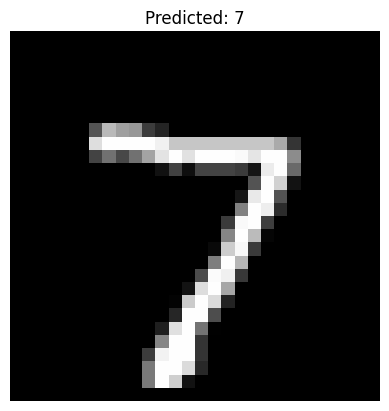

In [11]:
## (Prediction + Image) :

predictions = model.predict(X_test)

index = 0
plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[index])}")
plt.axis('off')
plt.show()

## Conclusion

- EarlyStopping halted training early, preventing unnecessary epochs
- Dropout reduced overfitting slightly
- Validation accuracy remained stable (~98%)
- Model generalizes well without excessive complexity

This version improves training efficiency compared to the baseline model.